In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv(
    "IMDb Movies India.csv",
    encoding="latin1"
)

In [5]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
df.shape

(15509, 10)

In [7]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


In [9]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

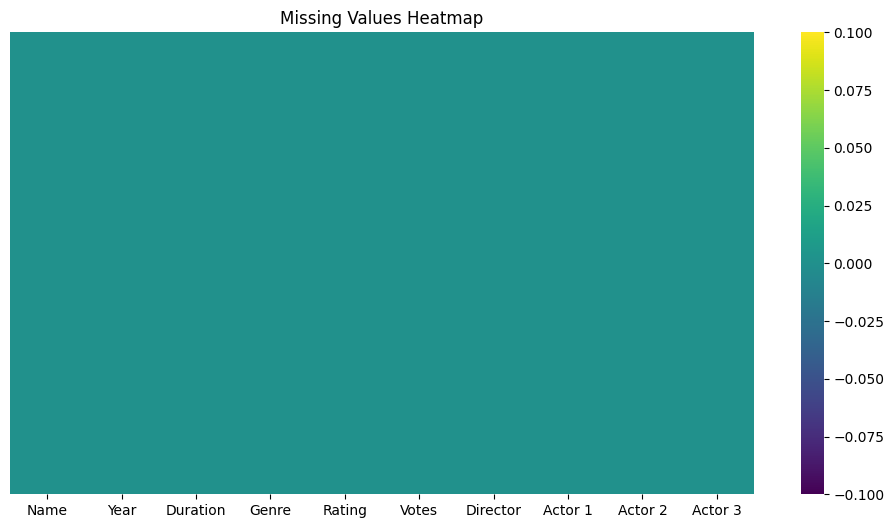

In [33]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap="viridis",
    yticklabels=False
)

plt.title(
    "Missing Values Heatmap"
)

plt.show()

In [10]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


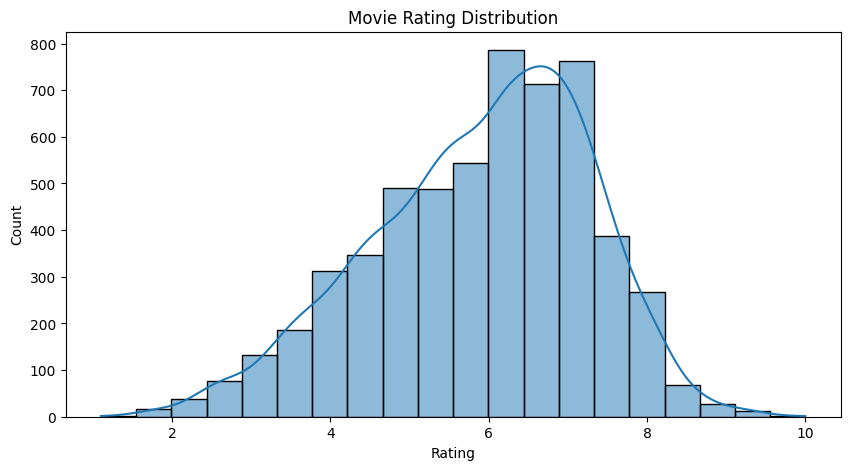

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title(
    "Movie Rating Distribution"
)

plt.xlabel(
    "Rating"
)

plt.show()

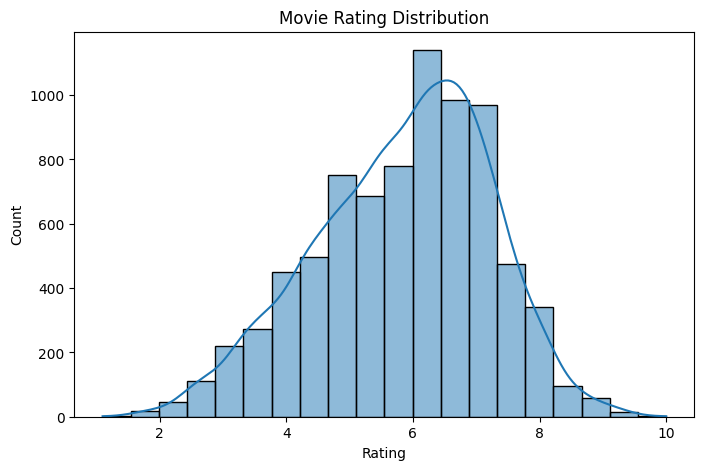

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title(
    "Movie Rating Distribution"
)

plt.show()

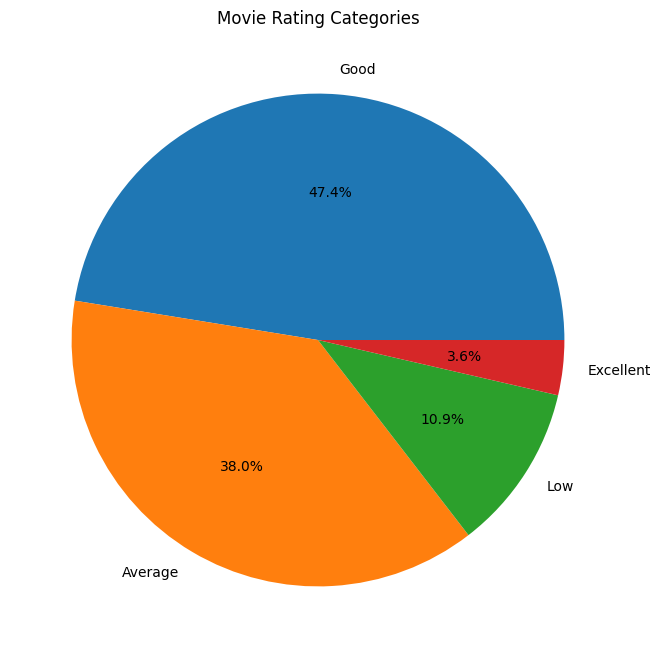

In [35]:
rating_group = pd.cut(
    df["Rating"],
    bins=[0,4,6,8,10],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ]
)

rating_group.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title(
    "Movie Rating Categories"
)

plt.show()

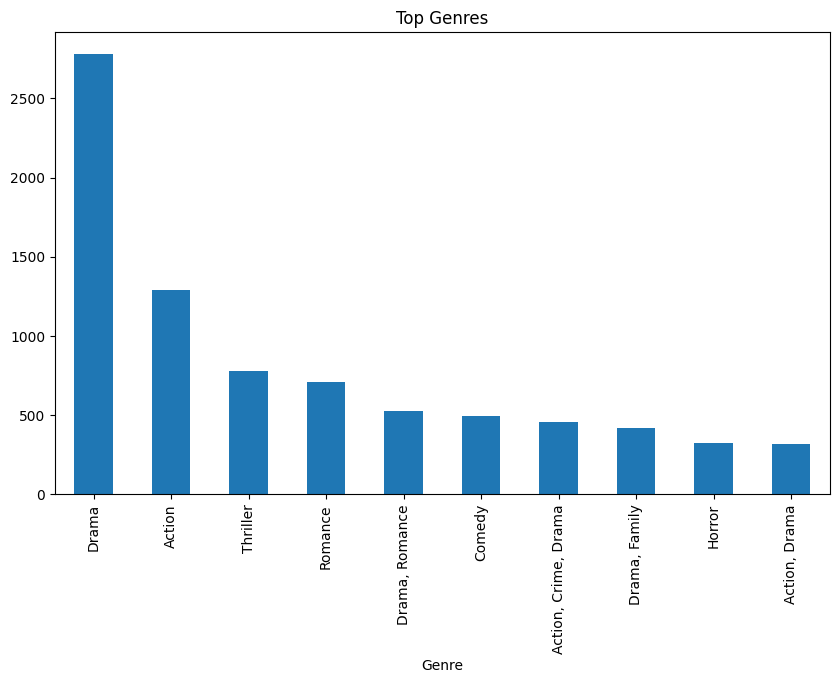

In [12]:
plt.figure(figsize=(10,6))

df["Genre"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top Genres"
)

plt.show()

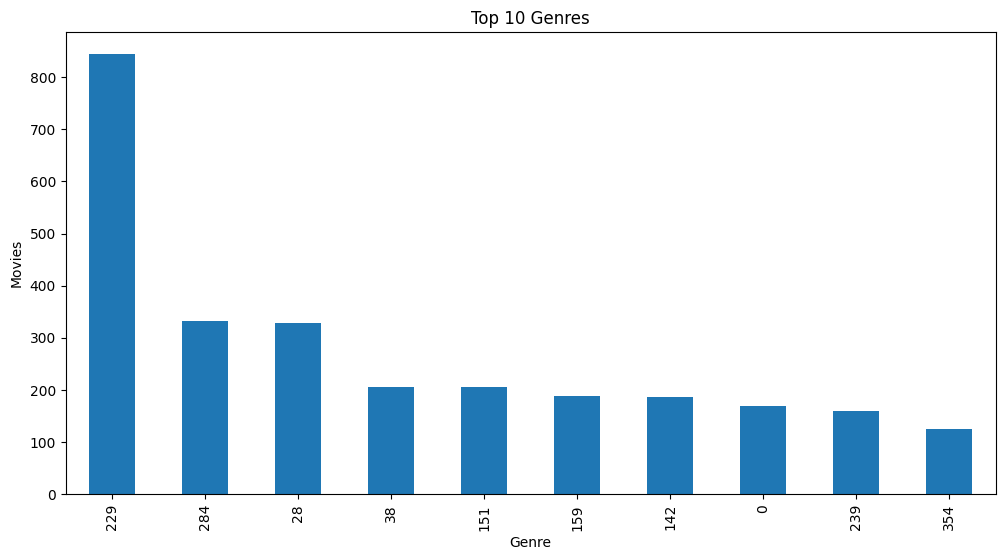

In [36]:
plt.figure(figsize=(12,6))

df["Genre"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Genres"
)

plt.xlabel(
    "Genre"
)

plt.ylabel(
    "Movies"
)

plt.show()

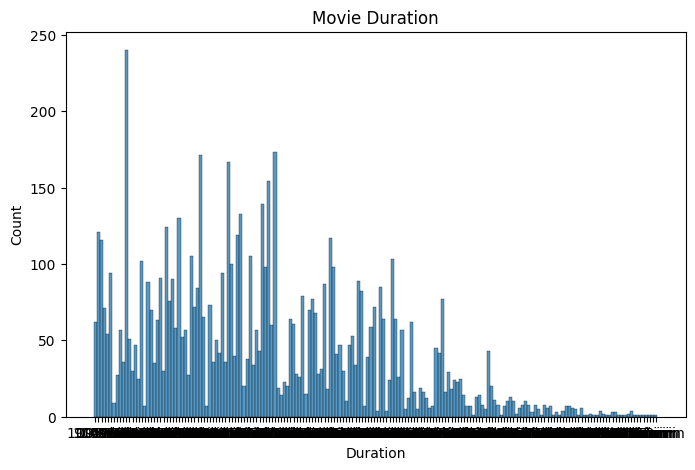

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Duration"],
    bins=20
)

plt.title(
    "Movie Duration"
)

plt.show()

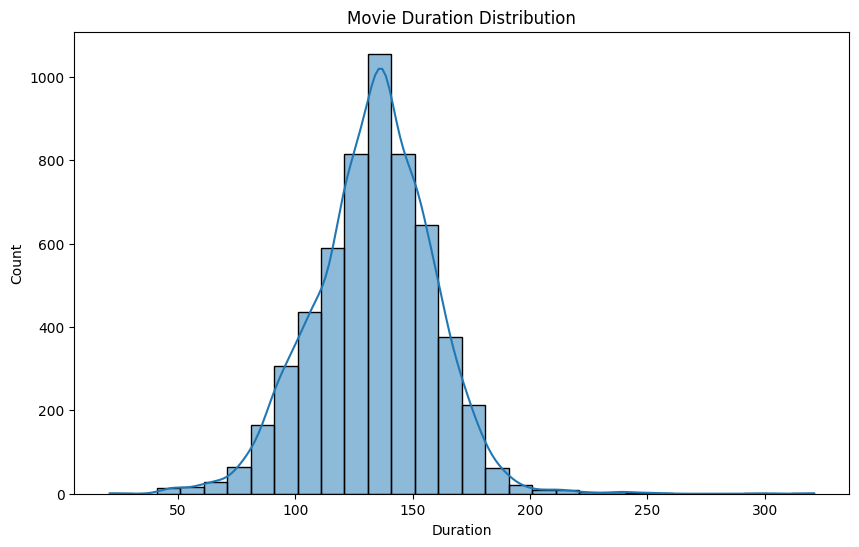

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Duration"],
    bins=30,
    kde=True
)

plt.title(
    "Movie Duration Distribution"
)

plt.show()

In [14]:
df = df.dropna(
    subset=["Rating"]
)

In [15]:
df = df.dropna()

In [16]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [17]:
df["Year"] = df["Year"].str.extract(
    r"(\d+)"
)

df["Year"] = df["Year"].astype(int)

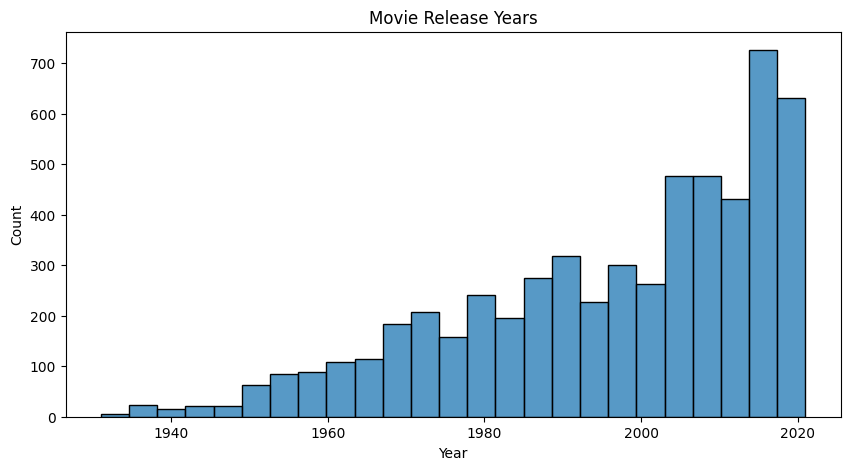

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Year"],
    bins=25
)

plt.title(
    "Movie Release Years"
)

plt.show()

In [18]:
df["Duration"] = (
    df["Duration"]
    .str.replace(
        " min",
        "",
        regex=False
    )
)

df["Duration"] = (
    df["Duration"]
    .astype(int)
)

In [19]:
df["Votes"] = (
    df["Votes"]
    .astype(str)
    .str.replace(
        ",",
        ""
    )
)

df["Votes"] = (
    pd.to_numeric(
        df["Votes"]
    )
)

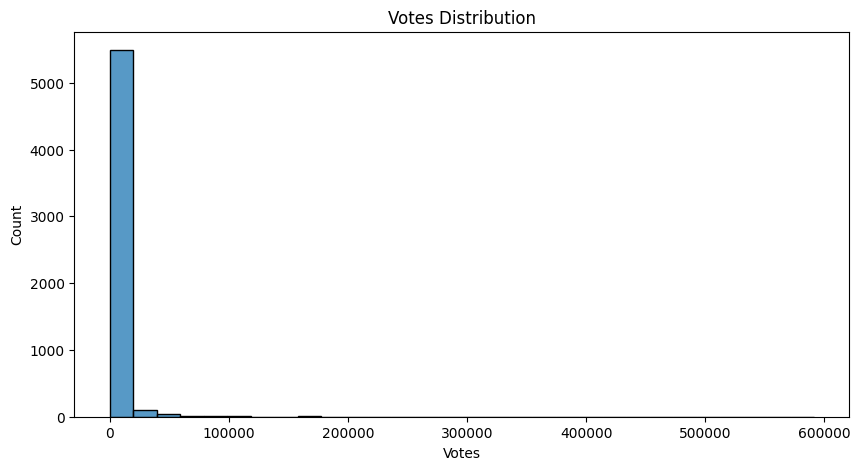

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Votes"],
    bins=30
)

plt.title(
    "Votes Distribution"
)

plt.show()

In [20]:
encoder = LabelEncoder()

In [21]:
columns = [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3",
    "Name"
]

for col in columns:
    df[col] = encoder.fit_transform(
        df[col]
    )

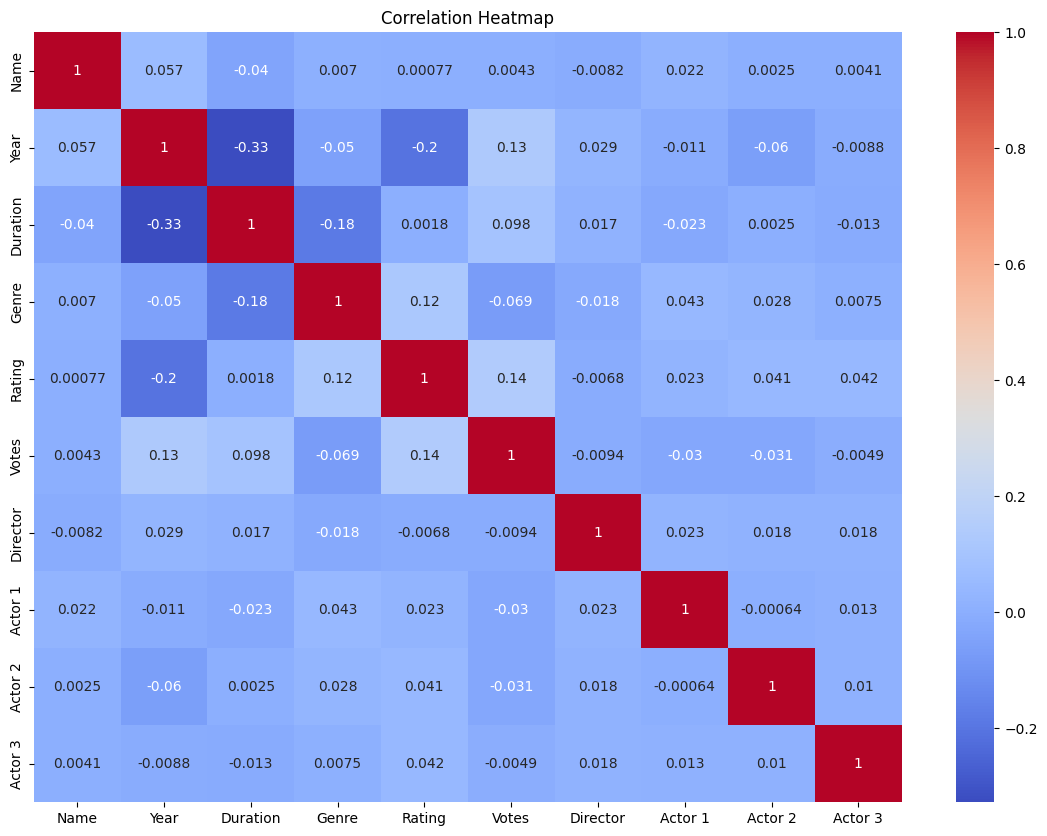

In [40]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

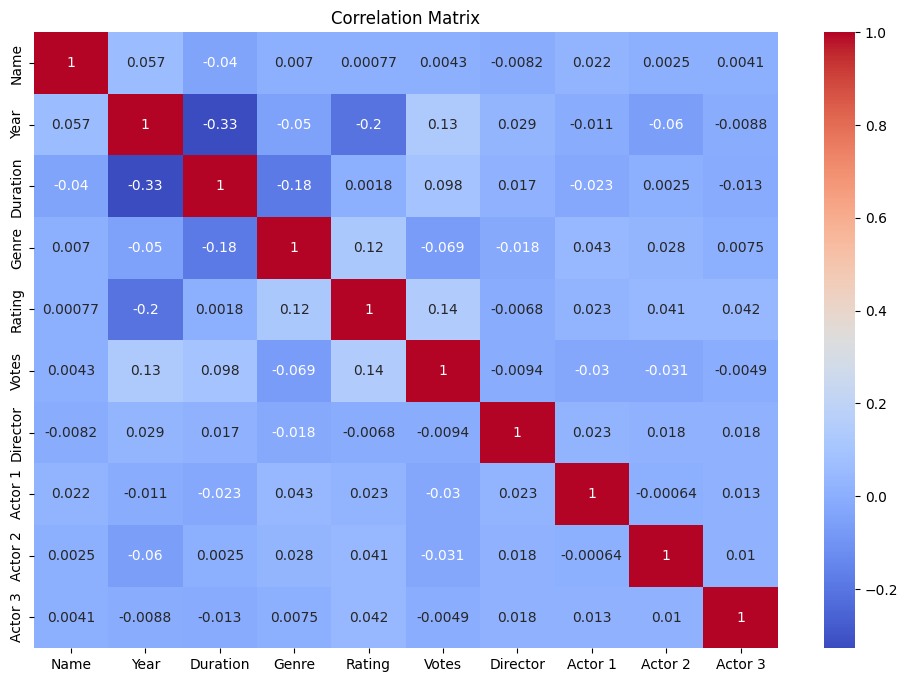

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [23]:
X = df.drop(
    "Rating",
    axis=1
)

In [24]:
y = df["Rating"]

In [25]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
y_pred = model.predict(
    X_test
)

In [28]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(
    "MAE:",
    mae
)

MAE: 0.8542888692579506


In [29]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(
    "RMSE:",
    rmse
)

RMSE: 1.1269256181931127


In [30]:
r2 = r2_score(
    y_test,
    y_pred
)

print(
    "R2 Score:",
    r2
)

R2 Score: 0.3141807984095203


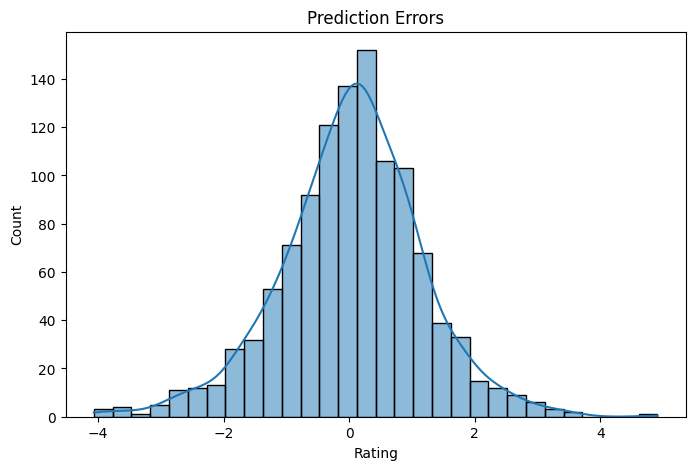

In [42]:
errors = y_test-y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.title(
    "Prediction Errors"
)

plt.show()

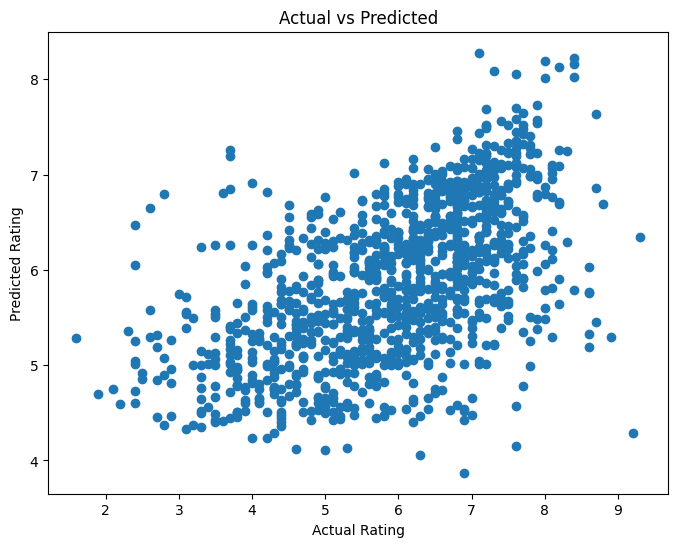

In [31]:
plt.figure(
    figsize=(8,6)
)

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Rating"
)

plt.ylabel(
    "Predicted Rating"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

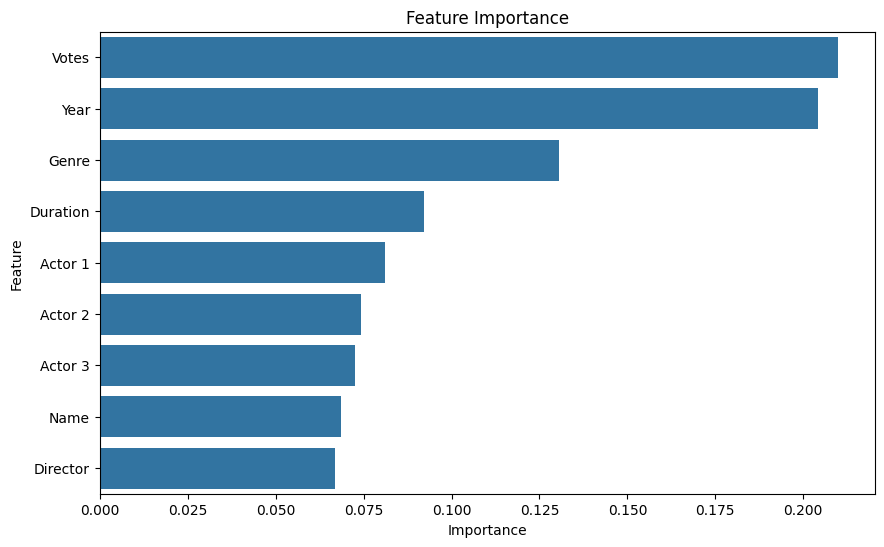

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

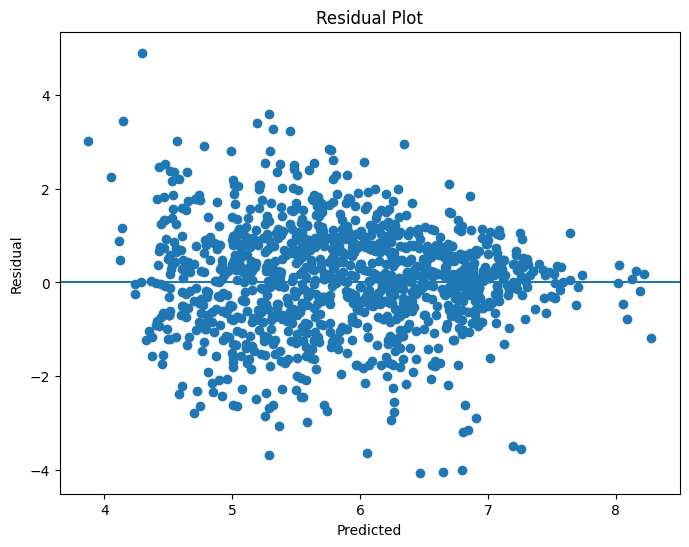

In [43]:
residuals = y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0
)

plt.title(
    "Residual Plot"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Residual"
)

plt.show()

Movie Rating Prediction using Random Forest Regressor.

Performed:
1. Data Loading
2. EDA
3. Data Cleaning
4. Feature Engineering
5. Encoding
6. Model Training
7. Evaluation

Successfully predicted movie ratings.